# Multi-Objective Optimisation for determination of optimal sequence of pipes to be repair under a number of crews based on the framework of the Battle of Postdisaster Response and Restoration (BPDRR)

This notebook is for running the MOO to select the sequence in which pipes are repaired using a given number of repair crews, based on the BPDRR framework.

To run this notebook, the following files are required as inputs. Make sure they are in the same folder as the notebook:
- **`BBM-EPS_DS*x*mcg.inp`**: The INP files of the Damage Scenarios used in the BPDRR.
- **`DS_with_full_description.xlsx`**: xlsx file that contains relevant information of the damage scenarios.
- **`TravelTime_DS*x*.parquet`**: parquet files with the travel times between pipes for each damage scenario.
- **`boundaries_norm_ideal.csv`**: csv file with the ideal Objective function (OF) values for each damage scenario.
- **`boundaries_norm_nadir.csv`**: csv file with reference nadir OF values for each damage scenario, meant to be used for normalisation along *`boundaries_norm_ideal.csv`*.

This notebook requires three Python files specific to this research, which are used as modules:
- **`OF_BPDRR.py`**: Contains the functions used to calculate the objective functions from the BPDRR.
- **`RC_scheduling.py`**: Contains the functions used to estimate the allocation and scheduling of the repair crews.
- **`visuals_BPDRR.py`**: Contains the functions used to generate the Pareto fronts and time-series plots.


### Part 1: Imports, Inputs and Constants

This section imports all the Python libraries and input files required for the optimisation process, including Excel files, Parquet files and EPANET INP models.

It also defines the constants and parameters that remain fixed throughout a single optimisation run. These values describe the restoration scenario and provide the information required by all subsequent stages of the optimisation framework.

In [1]:
import os
import pandas as pd
import wntr
import numpy as np
import dill 

In [2]:
# Import the specific pymoo functions required for the BPDRR problem
from pymoo.core.problem import ElementwiseProblem
from pymoo.operators.crossover.ox import OrderCrossover
from pymoo.operators.mutation.inversion import InversionMutation
from pymoo.operators.sampling.rnd import PermutationRandomSampling
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.optimize import minimize
from pymoo.core.termination import Termination
from pymoo.indicators.hv import HV
from pymoo.core.callback import Callback

In [3]:
# Import the specific modules of this research
import OF_BPDRR as OF
import RC_scheduling as rcs
import visuals_BPDRR as visuals

### Damage Scenario and Repair Crew Selection

> **User input:** Edit the cell below **before running the simulation** to select:
>
> * the **Damage Scenario** to analyze, and
> * the **number of repair crews** available for restoration.

The selected values will be used throughout the simulation.


In [4]:
# Damage scenario to analyse
ds_sel = 'DS5'

# Number of repair crews available for restoration
n_crews = 9

In [5]:
# Import the water network model
inp_file = "BBM-EPS_"+ds_sel+"mcg.inp"

# Variable where the wntr simulation of the selected scenario is run
wn = wntr.network.WaterNetworkModel(inp_file)

# The name of the temporal restoration input file that will be used during the optimisation process
temp_inp="temp_restoration.inp"

In [6]:
# Simulation settings
wn.options.time.duration = 7 * 24 * 3600       # Time duration of each WNTR simulation
wn.options.time.hydraulic_timestep = 15 * 60     # 15 minutes
wn.options.time.report_timestep = 15 * 60        # 15 minutes

# Start simulation at 07:00 AM
wn.options.time.start_clocktime = 7 * 3600

# Pressure Driven Analysis
wn.options.hydraulic.demand_model = "PDA"
wn.options.hydraulic.required_pressure = 20
wn.options.hydraulic.minimum_pressure = 0
wn.options.hydraulic.pressure_exponent = 0.5

In [7]:
# timestep
dt = wn.options.time.hydraulic_timestep

# timestep in minutes
dtm = dt/60

In [8]:
# Find all demand nodes (base demand > 0)
demand_nodes = []

# Expected demand at each node
#expected = {}

for node_name in wn.junction_name_list:

    node = wn.get_node(node_name)

    if node.base_demand > 0:

        demand_nodes.append(node_name)

print(f"Demand nodes found: {len(demand_nodes)}")

Demand nodes found: 4201


In [9]:
# Finding emitter nodes (nodes starting with "E_")
emitter_nodes = [
    j for j in wn.junction_name_list
    if j.startswith("E_")
]

In [10]:
# Expected demand
expected = wntr.metrics.expected_demand(wn)

expected *= 1000        # convert to L/s

expected = expected[demand_nodes]

expected.index = expected.index.astype(int)

In [11]:
# Read the repair times from the Excel file
df = pd.read_excel(
    "DS_with_full_description.xlsx",
    sheet_name= ds_sel
)

# Repair time discretization (hours)
repair_time_interval = 0.25  # 15 minutes

# Build the reparations dictionary
time_reparation = {}

for _, row in df.iterrows():

    repair_time = float(row["fix time (hours)"])

    # Round up to the nearest interval
    repair_time = np.ceil(repair_time / repair_time_interval) * repair_time_interval

    time_reparation[str(row["Pipe ID"])] = {
        "t_r": repair_time
    }

print(f"{len(time_reparation)} repairs loaded.")
# time_reparation

108 repairs loaded.


In [12]:
# Import the travel time matrix from the parquet file
dmatrix_df = pd.read_parquet(
    "TravelTime_"+ds_sel+".parquet"
)

# Normalise IDs so the repair dictionary and matrix use the same keys
dmatrix_df.index = dmatrix_df.index.map(str)
dmatrix_df.columns = dmatrix_df.columns.map(str)

In [13]:
# Pipe IDs from the reparations dictionary
pipe_ids = list(time_reparation.keys())

# List of indexes corresponding to the pipe IDs to be repaired
indexes = list(range(len(pipe_ids)))

In [14]:
# Normalization boundaries
norm_ideal = pd.read_csv(
    "boundaries_norm_ideal.csv",
    sep=";",
    index_col=0
)

norm_nadir = pd.read_csv(
    "boundaries_norm_nadir.csv",
    sep=";",
    index_col=0
)

# Normalisation bounds for the selected damage scenario
ideal_values = norm_ideal[ds_sel].to_numpy(dtype=float)
nadir_values = norm_nadir[ds_sel].to_numpy(dtype=float)

In [15]:
# The scenario dictionary contains all the information required to run the optimisation process
scenario = {
    
    # Restoration
    "damaged_inp": inp_file,
    "reparations": time_reparation,
    "dmatrix": dmatrix_df,
    "pipe_ids": pipe_ids,
    "n_crews": n_crews,
    "temp_inp": temp_inp,

    # Hydraulic data
    "demand_nodes": demand_nodes,
    "emitter_nodes": emitter_nodes,
    "expected": expected,

    # Time
    "dt": dt,
    "dtm": dtm,

    # Simulation settings
    "duration": wn.options.time.duration,
    "hydraulic_timestep": wn.options.time.hydraulic_timestep,
    "report_timestep": wn.options.time.report_timestep,

    "demand_model": wn.options.hydraulic.demand_model,
    "required_pressure": wn.options.hydraulic.required_pressure,
    "minimum_pressure": wn.options.hydraulic.minimum_pressure,
    "pressure_exponent": wn.options.hydraulic.pressure_exponent,

    # Objective constants
    "service_ratio": 0.5,
    "consecutive_hours": 8,
}

### Part 2: Restoration Simulation

This section defines the functions responsible for generating a repair schedule from a candidate solution, creating the corresponding EPANET controls, and performing the hydraulic simulation of the restoration process.

The output of this section is a hydraulic simulation that can be evaluated using the objective functions.

In [16]:
# Function to simulate the restoration process
def simulate_restoration(
    indexes,
    scenario,
    save_temp_inp=False,
):
    """
    Run one hydraulic restoration simulation.

    Parameters
    ----------
    indexes : list
        Permutation of damaged pipes (decision variable).

    scenario : dict
        Dictionary containing all fixed information for the
        restoration scenario.

    save_temp_inp : bool, optional
        If True, the temporary INP is kept after the simulation.
        Otherwise it is deleted.

    Returns
    -------
    simulation : dict

        {
            "results" : SimulationResults,
            "schedule": pandas.DataFrame,
            "network" : WaterNetworkModel
        }
    """

    # Create repair schedule
    schedule = rcs.create_schedule(
        reparations=scenario["reparations"],
        dmatrix=scenario["dmatrix"],
        pipe_ids=scenario["pipe_ids"],
        indexes=indexes,
        n_crews=scenario["n_crews"],
    )

    # Generate EPANET controls
    controls = rcs.generate_controls(
        schedule
    )

    # Create temporary INP
    rcs.write_inp_controls(
        input_inp=scenario["damaged_inp"],
        output_inp=scenario["temp_inp"],
        schedule=schedule,
        new_controls=controls,
    )

    # Load temporary network
    wn = wntr.network.WaterNetworkModel(scenario["temp_inp"])

    wn.options.time.duration = scenario["duration"]
    wn.options.time.hydraulic_timestep = scenario["hydraulic_timestep"]
    wn.options.time.report_timestep = scenario["report_timestep"]
    wn.options.hydraulic.demand_model = scenario["demand_model"]
    wn.options.hydraulic.required_pressure = scenario["required_pressure"]
    wn.options.hydraulic.minimum_pressure = scenario["minimum_pressure"]
    wn.options.hydraulic.pressure_exponent = scenario["pressure_exponent"]
   
    # Run hydraulic simulation    
    sim = wntr.sim.EpanetSimulator(wn)

    results = sim.run_sim()

    # Remove temporary INP
    if not save_temp_inp:

        try:
            os.remove(scenario["temp_inp"])

        except FileNotFoundError:
            pass

    # Return simulation
    simulation = {
        "results": results,
        "schedule": schedule,
        "network": wn,
    }

    return simulation

### Part 3: Objective Function Evaluation

This section evaluates the hydraulic simulation produced in Part 2 using the six objective functions being used.

The resulting objective vector represents the performance of a candidate repair schedule and will be used by the optimisation algorithm.

In [17]:
def evaluate_solution(
    indexes,
    scenario
):
    """
    Evaluate one restoration solution.

    Parameters
    ----------
    indexes : list or ndarray
        Permutation of damaged pipes.

    scenario : dict
        Dictionary containing all fixed information for the
        restoration scenario.

    Returns
    -------
    numpy.ndarray

        Objective vector:

        [
            FH,
            t95,
            RL,
            TNS,
            NWSECH,
            WL
        ]
    """

    # Run restoration simulation
    simulation = simulate_restoration(
        indexes,
        scenario,
        save_temp_inp=False,
    )

    # Extract hydraulic results
    results = simulation["results"]

    demand = results.node["demand"] * 1000  # convert to L/s

    # Supply ratio
    supply_ratio = (
        demand[scenario["demand_nodes"]]
        / scenario["expected"]
    )

    # Objective 1 - FH
    FH, _ = OF.OF_FH(
        supply_ratio=supply_ratio,
        dtm=scenario["dtm"],
    )

    # Objective 2 - t95
    t95 = OF.OF_t95(
        demand=demand,
        demand_nodes=scenario["demand_nodes"],
        expected=scenario["expected"],
        dtm=scenario["dtm"],
    )

    # Objective 3 - Resilience Loss
    RL = OF.OF_RL(
        demand=demand,
        demand_nodes=scenario["demand_nodes"],
        expected=scenario["expected"],
        dtm=scenario["dtm"],
    )

    # Objective 4 - Time without service
    TNS = OF.OF_time_no_serv(
        supply_ratio=supply_ratio,
        dtm=scenario["dtm"],
        ratio=scenario["service_ratio"],
    )

    # Objective 5 - Nodes without service > 8 h
    NWSECH = OF.OF_NWSECH(
        supply_ratio=supply_ratio,
        dtm=scenario["dtm"],
        ratio=scenario["service_ratio"],
        hours=scenario["consecutive_hours"],
    )

    # Objective 6 - Water loss
    WL = OF.OF_WL(
        demand=demand,
        emitter_nodes=scenario["emitter_nodes"],
        dt=scenario["dt"],
    )

    # Objective vector
    objectives = np.array([
        FH,
        t95,
        RL,
        TNS,
        NWSECH,
        WL,
    ])

    return objectives

In [18]:
solution = evaluate_solution(indexes, scenario)
print(f"{solution[0]:.2f}, {solution[1]:.2f}, {solution[2]:.2f}, {solution[3]:.2f}, {solution[4]}, {solution[5]:.2f}")

705.00, 4020.00, 16150.44, 84.49, 248.0, 50826.34


### Part 4: Multi-Objective Optimisation

This section defines the optimisation problem and configures the NSGA-III algorithm. Candidate repair schedules are generated, evaluated and evolved to approximate the Pareto-optimal set of permutations of the pipe repair orders.

In [19]:
# Class for the problem where OF values are normalized
class BPDRRProblem(ElementwiseProblem):
    """
    Multi-objective restoration scheduling problem.

    Decision variable:
        Permutation of the damaged pipes.

    Objectives:
        1. FH
        2. t95
        3. RL
        4. Time without service
        5. NWSECH
        6. Water loss

    The objective functions are normalized using scenario-specific
    ideal and nadir reference values.
    """

    def __init__(
        self,
        scenario,
        ideal_values,
        nadir_values
    ):

        self.scenario = scenario
        self.n_eval = 0

        # Store raw objective values for inspection
        self.raw_objectives = {}

        # Store normalization boundaries
        self.ideal_values = np.asarray(
            ideal_values,
            dtype=float
        )

        self.nadir_values = np.asarray(
            nadir_values,
            dtype=float
        )

        # Check that the boundaries are valid
        if len(self.ideal_values) != 6:
            raise ValueError(
                "ideal_values must contain 6 objective values."
            )

        if len(self.nadir_values) != 6:
            raise ValueError(
                "nadir_values must contain 6 objective values."
            )

        if not np.all(self.nadir_values > self.ideal_values):
            raise ValueError(
                "Every nadir value must be greater than "
                "the corresponding ideal value."
            )

        n_pipes = len(scenario["pipe_ids"])

        super().__init__(
            n_var=n_pipes,
            n_obj=6,
            n_ieq_constr=0,
            xl=0,
            xu=n_pipes - 1,
            vtype=int,
        )

    def _evaluate(self, x, out, *args, **kwargs):

        self.n_eval += 1

        # Convert to integer permutation
        indexes = np.asarray(x, dtype=int)

        # Evaluate restoration schedule
        objectives = evaluate_solution(
            indexes=indexes,
            scenario=self.scenario,
        )

        # Convert to NumPy array
        objectives = np.asarray(
            objectives,
            dtype=float
        )

        # Store the original, unnormalised objectives
        self.raw_objectives[tuple(indexes)] = objectives.copy()

        # Normalise objectives
        normalised_objectives = (objectives - self.ideal_values) / (self.nadir_values - self.ideal_values)

        # Pymoo minimizes all objectives
        out["F"] = normalised_objectives

In [20]:
class HVTermination(Termination):
    """
    Termination criterion based on the relative improvement
    in hypervolume over a sliding window.

    The optimisation stops when either:

    1. The maximum relative improvement in hypervolume over
       the specified number of generations is below the
       specified threshold, or
    2. The maximum number of function evaluations is reached.
    """

    def __init__(
        self,
        max_evals,
        window=10,
        hv_threshold=0.3,
        ref_point=None
    ):
        super().__init__()

        self.max_evals = max_evals
        self.window = window
        self.hv_threshold = hv_threshold
        self.ref_point = ref_point

        self.hv_history = []
        self.relative_improvements = []

    def _update(self, algorithm):


        # Calculate hypervolume
        F = algorithm.pop.get("F")

        hv_indicator = HV(ref_point=self.ref_point)

        current_hv = hv_indicator.do(F)

        self.hv_history.append(current_hv)

        # Calculate relative HV improvement

        if len(self.hv_history) == 1:

            relative_improvement = 0.0

        else:

            previous_hv = self.hv_history[-2]

            if previous_hv == 0:

                # Avoid division by zero
                if current_hv > 0:
                    relative_improvement = np.inf
                else:
                    relative_improvement = 0.0

            else:

                relative_improvement = (
                    (current_hv - previous_hv)
                    / abs(previous_hv)
                    * 100
                )

        self.relative_improvements.append(
            relative_improvement
        )

        # 3. Check the sliding-window criterion
        if len(self.relative_improvements) >= self.window:

            recent_improvements = (
                self.relative_improvements[-self.window:]
            )

            max_relative_improvement = max(
                recent_improvements
            )

            print(
                f"Generation {algorithm.n_gen}: "
                f"HV = {current_hv:.5f} | "
                f"{self.window}-gen max relative improvement = "
                f"{max_relative_improvement:.2f}%"
            )

            if max_relative_improvement < self.hv_threshold:

                print(
                    f"Termination: all relative HV improvements "
                    f"over the last {self.window} generations "
                    f"are below {self.hv_threshold}%."
                )

                return 1.0

        # 4. Check maximum function evaluations
        if algorithm.evaluator.n_eval >= self.max_evals:

            print(
                f"Termination: maximum number of function "
                f"evaluations reached ({self.max_evals})."
            )

            return 1.0

        return 0.0

In [21]:
# Checkpoint that allows a backup save file. It saves after each generation created. 
class CheckpointCallback(Callback):

    def __init__(self, filename="NSGA3_checkpoint.pkl"):
        super().__init__()
        self.filename = filename

    def notify(self, algorithm):

        temp_filename = self.filename + ".tmp"

        with open(temp_filename, "wb") as f:
            dill.dump(algorithm, f)

        os.replace(temp_filename, self.filename)

        print(
            f"Checkpoint saved: "
            f"Generation {algorithm.n_gen}"
        )

In [22]:
problem = BPDRRProblem(
    scenario=scenario,
    ideal_values=ideal_values,
    nadir_values=nadir_values
)

x = np.array(indexes)

out = {}

problem._evaluate(x, out)

print("Normalised objectives:")
print(out["F"])

Normalised objectives:
[0.644 0.076 0.11  0.437 0.961 0.071]


In [23]:
# NSGA-III PARAMETERS
max_evals = 10000
seed = 3

# Reference directions
ref_dirs = get_reference_directions(
    "das-dennis",
    n_dim=6,
    n_partitions=4
)

# NSGA-III algorithm
algorithm = NSGA3(
    ref_dirs=ref_dirs,
    
    # Permutation-specific operators
    sampling=PermutationRandomSampling(),
    crossover=OrderCrossover(prob=0.9),
    mutation=InversionMutation(prob=0.4),    
    eliminate_duplicates=True
)

print(f"Number of reference directions: {len(ref_dirs)}")
print(f"Maximum function evaluations: {max_evals}")

Number of reference directions: 126
Maximum function evaluations: 10000


In [24]:
# Termination criterion. Stops if: 
# 1. Maximum relative HV improvement over (window) generations is < (hv_threshold)%, OR
# 2. Maximum of 10,000 function evaluations is reached
termination = HVTermination(
    max_evals=max_evals,
    window=15,
    hv_threshold=0.3,
    ref_point=np.ones(6) * 0.9
)

In [25]:
checkpoint_callback = CheckpointCallback(
    "NSGA3_checkpoint.pkl"
)

### Part 5: Results and Pareto Analysis

This section executes the optimisation process and analyses the resulting Pareto-optimal solutions. The objective values and repair schedules are compared to identify the trade-offs between different restoration strategies.

In [26]:
result = minimize(
    problem=problem,
    algorithm=algorithm,
    termination=termination,
    seed=seed,
    callback=checkpoint_callback,
    save_history=True,
    verbose=True,
)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      126 |     11 |             - |             -
Checkpoint saved: Generation 1
     2 |      252 |      8 |  0.1122673849 |         ideal
Checkpoint saved: Generation 2
     3 |      378 |      9 |  0.3223418771 |         ideal
Checkpoint saved: Generation 3
     4 |      504 |      8 |  0.1796215175 |         ideal
Checkpoint saved: Generation 4
     5 |      630 |     12 |  0.2607074594 |         ideal
Checkpoint saved: Generation 5
     6 |      756 |     14 |  0.0863086901 |         ideal
Checkpoint saved: Generation 6
     7 |      882 |     12 |  0.3416059602 |         ideal
Checkpoint saved: Generation 7
     8 |     1008 |     10 |  0.3173114668 |         ideal
Checkpoint saved: Generation 8
     9 |     1134 |     14 |  0.0305690073 |         ideal
Checkpoint saved: Generation 9
    10 |     1260 |     12 |  0.1399472914 |         ideal
Checkpoint saved: Generation 10
    11 |     1386 |     16 |  0.22799413

### Resume from checkpoint

If a run gets interrupted and you want to resume the optimization from the last saved checkpoint, follow these instructions:

1. Uncomment the code cell below, **"Algorithm to resume the run from the last saved checkpoint"**.
2. Skip the cell containing the **NSGA-III algorithm definition**. The algorithm will be loaded from the checkpoint instead.
3. Skip the cell containing the **normal `minimize()` run** (the one above this markdown).
4. Run the notebook again. The optimization will resume from the last saved checkpoint. 

In [ ]:
# # Algorithm to resume the run from the last saved checkpoint
# with open("NSGA3_checkpoint.pkl", "rb") as f:
#     algorithm_checkpoint = dill.load(f)

# result = minimize(
#     problem=problem,
#     algorithm=algorithm_checkpoint,
#     copy_algorithm=False,
#     callback=checkpoint_callback,
#     save_history=True,
#     verbose=True,
# )

In [28]:
# Retrieve the complete optimisation history
history = result.history

# Objective names
objective_names = [
    "FH",
    "t95",
    "RL",
    "TNS",
    "NWSECH",
    "WL"
]

history_OF = []
history_index = []

for generation in history:

    generation_number = generation.n_gen

    # Normalised objective values stored by pymoo
    F_normalised = generation.pop.get("F")

    # Convert back to the original objective values
    F_raw = (
        F_normalised
        * (nadir_values - ideal_values)
        + ideal_values
    )

    for solution_number, objectives in enumerate(F_raw):

        history_OF.append(objectives)

        history_index.append(
            (generation_number, solution_number)
        )


history_index = pd.MultiIndex.from_tuples(
    history_index,
    names=["Generation", "Solution"]
)

pareto_OF_history = pd.DataFrame(
    history_OF,
    index=history_index,
    columns=objective_names
)

pareto_OF_history

FH     t95            RL        TNS  NWSECH  \
Generation Solution                                                   
1          0         630.0  4020.0  12558.369928  44.496548    76.0   
           1           0.0  5460.0  11045.768960  46.546060   137.0   
           2           0.0  4020.0  11613.276734  41.715068    78.0   
           3         615.0  4140.0  13176.263968  50.959295   102.0   
           4           0.0  4080.0  11916.646486  25.011902    22.0   
...                    ...     ...           ...        ...     ...   
65         121       600.0  4020.0  11334.517228  50.377291    86.0   
           122         0.0  4020.0   7733.716547  18.109974    11.0   
           123         0.0  4020.0   8335.338950  21.341347    27.0   
           124         0.0  4020.0   8406.525847  32.278029    65.0   
           125         0.0  4020.0   8337.930663  25.790288    23.0   

                               WL  
Generation Solution                
1          0         58777.937500  
           1         58149.062500  
           2         58441.621094  
           3         57805.882812  
           4         62003.855469  
...                           ...  
65         121       48640.683594  
           122       50761.878906  
           123       50026.457031  
           124       49200.824219  
           125       49307.343750  

[8190 rows x 6 columns]

In [29]:
# Code to create a dataframe that contains the index order of the solutions
history_solutions = []
history_index = []

for generation in history:

    generation_number = generation.n_gen

    X = generation.pop.get("X")

    for solution_number, x in enumerate(X):

        history_solutions.append(x)

        history_index.append(
            (generation_number, solution_number)
        )

history_index = pd.MultiIndex.from_tuples(
    history_index,
    names=["Generation", "Solution"]
)

pareto_solutions_history = pd.DataFrame(
    history_solutions,
    index=history_index
)

pareto_solutions_history

0    1    2    3    4    5    6    7    8    9    ...  \
Generation Solution                                                    ...   
1          0          99   84   23   97   87   57   16   71   45   53  ...   
           1          57   45   19   34   20   85    3   56   35   14  ...   
           2          22   77   15   13   57   56   91   94   84   18  ...   
           3           6   44   92    4   72   28   43   15   88    2  ...   
           4          95   24   49   34   37   43   27   21   67   78  ...   
...                  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
65         121        32    3    0    2    1   38   49    4   39    5  ...   
           122        31    0    5    2    6    1    3   98   32   35  ...   
           123         3    4    5    2    1    6    0   32   49    7  ...   
           124         2    0   31    1    3   32   61    4    5    6  ...   
           125         2   44   45    6    1    3    4   32    0    5  ...   

                     98   99   100  101  102  103  104  105  106  107  
Generation Solution                                                    
1          0          27   38   49   40   18   95   82   69    6   19  
           1          47   84   43   44   33   78   30   46  107  101  
           2          39   12   69  106   86   45   88   47   71   49  
           3          16   81   13   66   65   17   23  106   93  104  
           4           4   90   53   55   58   38   92   54   16   41  
...                  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  
65         121       103   97   87   13   94  102   22   82   85   79  
           122        97   22  103   67   21   85   27   34   80   25  
           123        71  103   97   13  102   27   82   69   99   19  
           124        70   81   16   86   94   85   17   27   96   25  
           125        22   21  103   64   71   85   19   80   86   27  

[8190 rows x 108 columns]

In [30]:
# Export as csv files the dataframes of the OF values and index order of the solutions
pareto_OF_history.to_csv(
    f"pareto_OF_history_{ds_sel}_{n_crews}RC.csv"
)

pareto_solutions_history.to_csv(
    f"pareto_solutions_history_{ds_sel}_{n_crews}RC.csv"
)

### Part 6: Visuals
This section generates the visual representations of the simulation results such as pareto fronts, functionality time series and water loss time series of an specific solution.

In [31]:
data = pareto_OF_history.copy()

In [32]:
# Dictionary to store information for the plot title
plot_info = {
    "scenario": ds_sel,
    "crews": n_crews
}

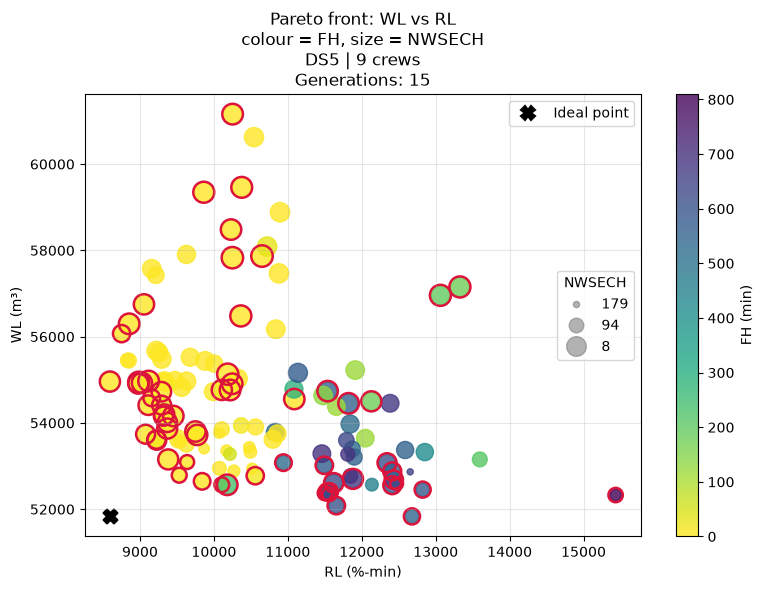

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Pareto front: WL vs RL\ncolour = FH, size = NWSECH\nDS5 | 9 crews\nGenerations: 15'}, xlabel='RL (%-min)', ylabel='WL (m³)'>)

In [33]:
# Pareto front plot using four objective functions
# Names of the objective functions to choose: FH, t95, RL, TNS, NWSECH, WL
# Generations: specify the generations to plot (e.g. [15] or [48, 49, 50])
visuals.plot_pareto_OF_MG(
    data=data,
    obj1="RL",
    obj2="WL",
    color_obj="FH",
    size_obj="NWSECH",
    plot_info=plot_info,
    generations=[15]
)